# How Popular Music Has Changed Over Time
### Billboard Hot 100 × MusicBrainz — 1958–2024

**Data sources**
| Source | What we get |
|---|---|
| Billboard Hot 100 CSV (Kaggle) | Chart rank, weeks on chart, peak position, 1958–2024 |
| MusicBrainz REST API | Track duration, release year, genre tags, artist country, label |

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

from src.analysis import (
    load_merged,
    summary_by_decade,
    plot_duration_over_time,
    plot_country_origins,
    plot_country_over_time,
    plot_weeks_on_chart_over_time,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')


Libraries loaded.


## 1. Load the merged dataset

In [2]:
df = load_merged()   # loads data/processed/merged_dataset.csv
print(f'Rows: {len(df):,}  |  Columns: {len(df.columns)}')
print(f'Date range: {df["chart_date"].min().date()} → {df["chart_date"].max().date()}')
print(f'Unique songs: {df[["title","artist"]].drop_duplicates().shape[0]:,}')
df.head()

Rows: 343,600  |  Columns: 17
Date range: 1958-08-04 → 2024-06-08
Unique songs: 31,344


,chart_date,year,decade,rank,title,artist,peak_position,weeks_on_chart,duration_sec,duration_min,mb_duration_ms,primary_genre,mb_genre_tags,mb_artist_country,mb_label,mb_release_year,last_week
0,1990-06-16,1990,1990s,54,"""B"" Girls",Young And Restless,54,7,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,55.0
1,1990-06-09,1990,1990s,55,"""B"" Girls",Young And Restless,55,6,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,58.0
2,1990-06-23,1990,1990s,57,"""B"" Girls",Young And Restless,54,8,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,54.0
3,1990-06-02,1990,1990s,58,"""B"" Girls",Young And Restless,58,5,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,60.0
4,1990-05-26,1990,1990s,60,"""B"" Girls",Young And Restless,60,4,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,68.0


In [3]:
# Data coverage
coverage = pd.DataFrame({
    'Column': df.columns,
    'Non-null %': (df.notna().mean() * 100).round(1).values
}).sort_values('Non-null %', ascending=False)
display(coverage)

,Column,Non-null %
0,chart_date,100.0
1,year,100.0
2,decade,100.0
3,rank,100.0
4,title,100.0
5,artist,100.0
6,peak_position,100.0
7,weeks_on_chart,100.0
16,last_week,90.6
13,mb_artist_country,79.4


## 1.5. Data Preparation — Genre Cleaning & Song-Level View

MusicBrainz tags are crowd-sourced and noisy (e.g. *"2008 universal fire victim"* is not a genre).  
We map raw tags to a smaller set of broad genres, and collapse the weekly chart rows to  
one row per unique song so that a long-charting song doesn't outweigh a short-charting one  
in genre/duration/country analyses.


In [4]:
# ── Broad-genre map ──────────────────────────────────────────────────────────
genre_map = {
    'rock':       'Rock',
    'metal':      'Rock',
    'punk':       'Rock',
    'pop':        'Pop',
    'hip hop':    'Hip-Hop/Rap',
    'rap':        'Hip-Hop/Rap',
    'r&b':        'R&B/Soul',
    'soul':       'R&B/Soul',
    'country':    'Country',
    'dance':      'Dance/Electronic',
    'electronic': 'Dance/Electronic',
    'disco':      'Dance/Electronic',
    'latin':      'Latin',
    'jazz':       'Jazz',
    'folk':       'Folk',
}

def assign_broad_genre(tags_str):
    """Map a comma-separated MusicBrainz tag string to one broad genre."""
    if pd.isna(tags_str):
        return None
    tags = [t.strip().lower().replace('-', ' ') for t in str(tags_str).split(',')]
    for tag in tags:
        for keyword, broad in genre_map.items():
            if keyword in tag:
                return broad
    return None

df['broad_genre'] = df['mb_genre_tags'].apply(assign_broad_genre)

# ── Song-level dataset (one row per unique song) ─────────────────────────────
song_level = (
    df.sort_values('chart_date')
      .groupby(['title', 'artist'], as_index=False)
      .agg(
          first_chart_date=('chart_date', 'min'),
          year=('year', 'min'),
          decade=('decade', 'first'),
          best_rank=('rank', 'min'),
          peak_position=('peak_position', 'min'),
          total_weeks=('weeks_on_chart', 'max'),
          duration_sec=('duration_sec', 'first'),
          mb_genre_tags=('mb_genre_tags', 'first'),
          mb_artist_country=('mb_artist_country', 'first'),
          mb_release_year=('mb_release_year', 'first'),
      )
)
song_level['broad_genre'] = song_level['mb_genre_tags'].apply(assign_broad_genre)

print(f'Song-level dataset : {len(song_level):,} unique songs')
print(f'Broad genre coverage: {song_level["broad_genre"].notna().mean()*100:.1f}% of songs')
print(f'\nGenre breakdown:\n{song_level["broad_genre"].value_counts().to_string()}')
song_level.head()


Song-level dataset : 31,344 unique songs
Broad genre coverage: 70.1% of songs

Genre breakdown:
broad_genre
Rock                6073
Pop                 4708
R&B/Soul            4217
Country             2561
Hip-Hop/Rap         1990
Dance/Electronic    1313
Jazz                 688
Folk                 351
Latin                 81


,title,artist,first_chart_date,year,decade,best_rank,peak_position,total_weeks,duration_sec,mb_genre_tags,mb_artist_country,mb_release_year,broad_genre
0,"""B"" Girls",Young And Restless,1990-05-05,1990,1990s,54,54,15,240.0,NaN,US,1990.0,NaN
1,"""Cherry Cherry"" from Hot August Night",Neil Diamond,1973-03-17,1973,1970s,31,31,10,NaN,NaN,NaN,NaN,NaN
2,"""Having A Party"" Medley",The Ovations (Featuring Louis Williams),1973-10-13,1973,1970s,56,56,9,NaN,NaN,NaN,NaN,NaN
3,"""Joy"" Pt. I",Isaac Hayes,1973-12-22,1973,1970s,30,30,9,NaN,NaN,NaN,NaN,NaN
4,"""Roots"" Medley",Quincy Jones,1977-03-05,1977,1970s,57,57,7,NaN,NaN,NaN,NaN,NaN


## 2. Summary by Decade

In [5]:
summary = summary_by_decade(df)
display(summary)

,Duration Sec,Weeks On Chart,Title
decade,,,
1950s,146.10,5.0,7400
1960s,158.00,5.0,52100
1970s,211.15,6.0,52200
1980s,246.10,7.0,52200
1990s,251.20,9.0,52100
2000s,232.00,10.0,52200
2010s,214.90,10.0,52200
2020s,191.00,9.0,23200


## 3. Song Duration Over Time
The 3-minute radio edit became an industry standard — but did streaming change it?

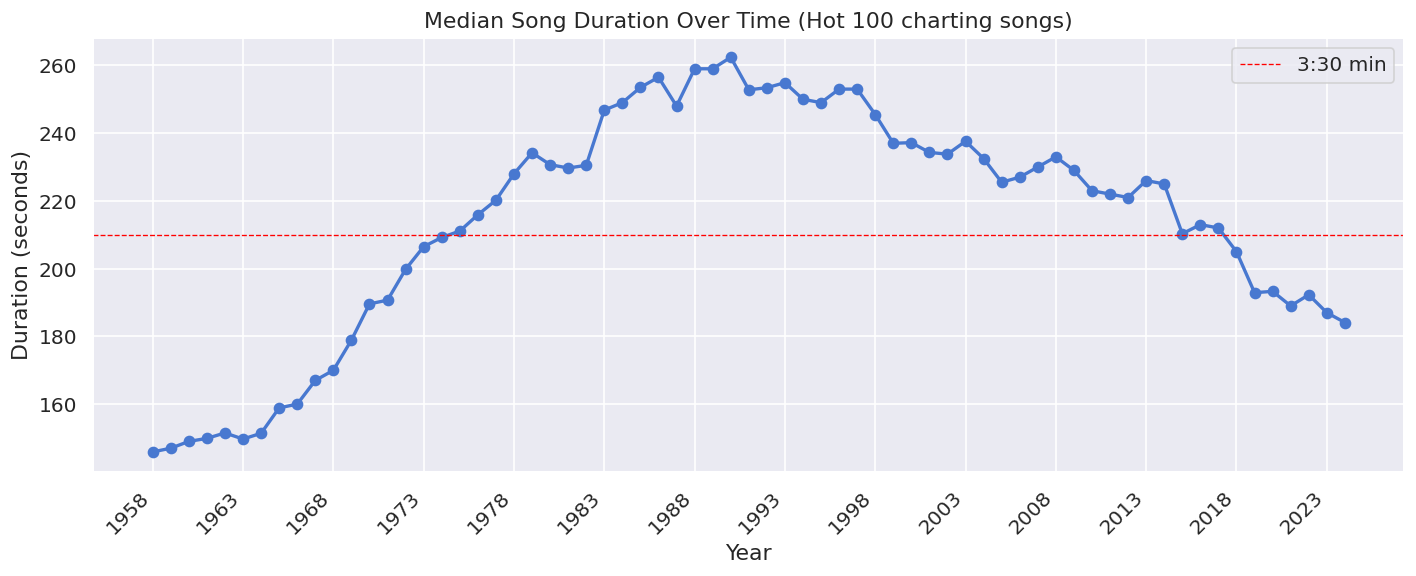

In [6]:
fig = plot_duration_over_time(df, by='year')
plt.show()

## 4. Genre Shifts by Decade
Rock → Pop → Hip-Hop — let's see it in the data.

*Using cleaned broad-genre labels (song-level, not weekly rows) to avoid bias from long-charting songs.*


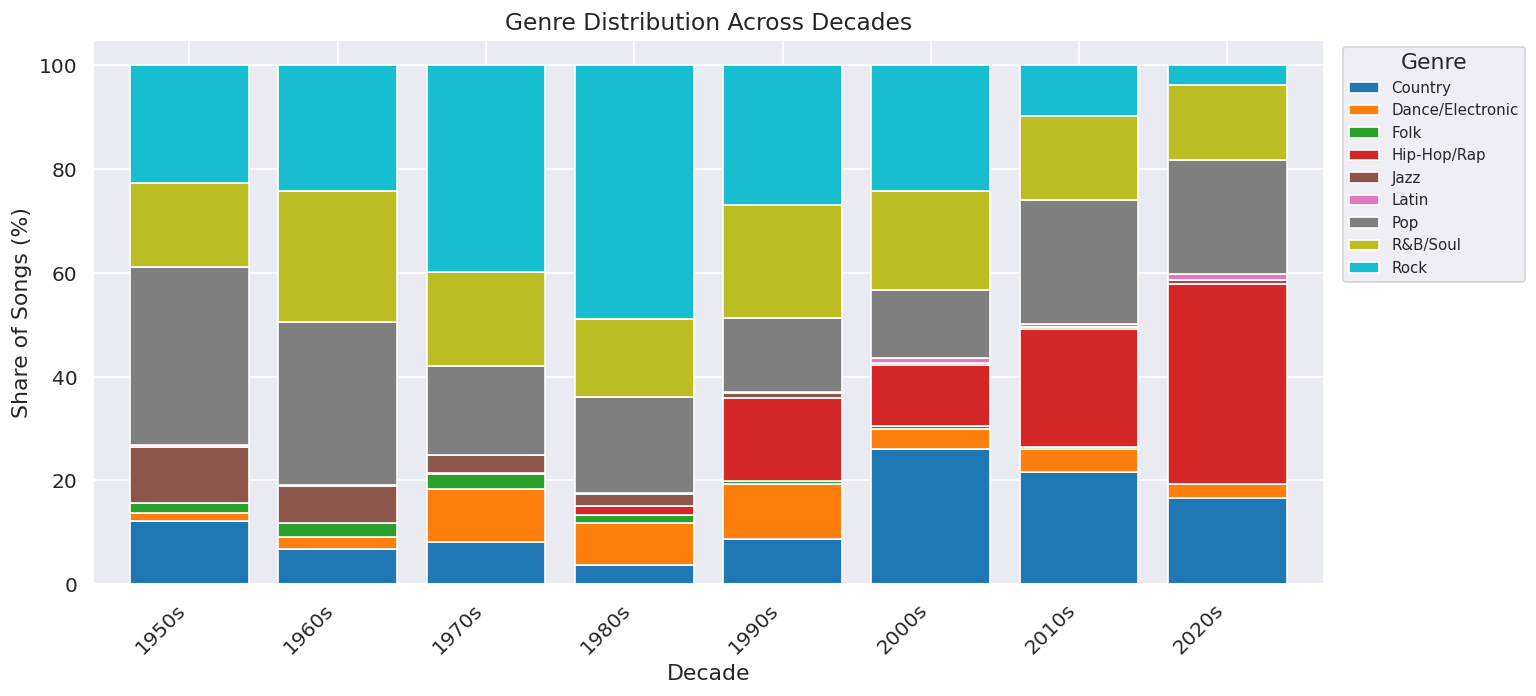

In [15]:
sub = song_level.dropna(subset=['broad_genre', 'decade'])
pivot = sub.groupby(['decade', 'broad_genre']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
pivot_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8, edgecolor='white')
ax.set_title('Genre Distribution Across Decades', fontsize=14)
ax.set_ylabel('Share of Songs (%)')
ax.set_xlabel('Decade')
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 5. Where Do Artists Come From?
Has the Hot 100 become more or less American over time?

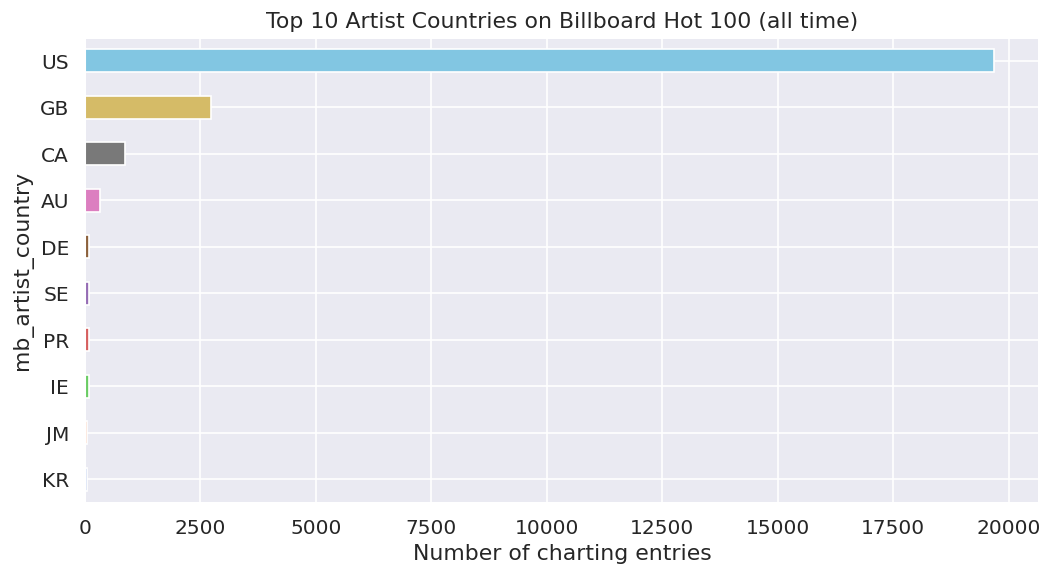

In [8]:
fig = plot_country_origins(song_level, top_n=10)
plt.show()


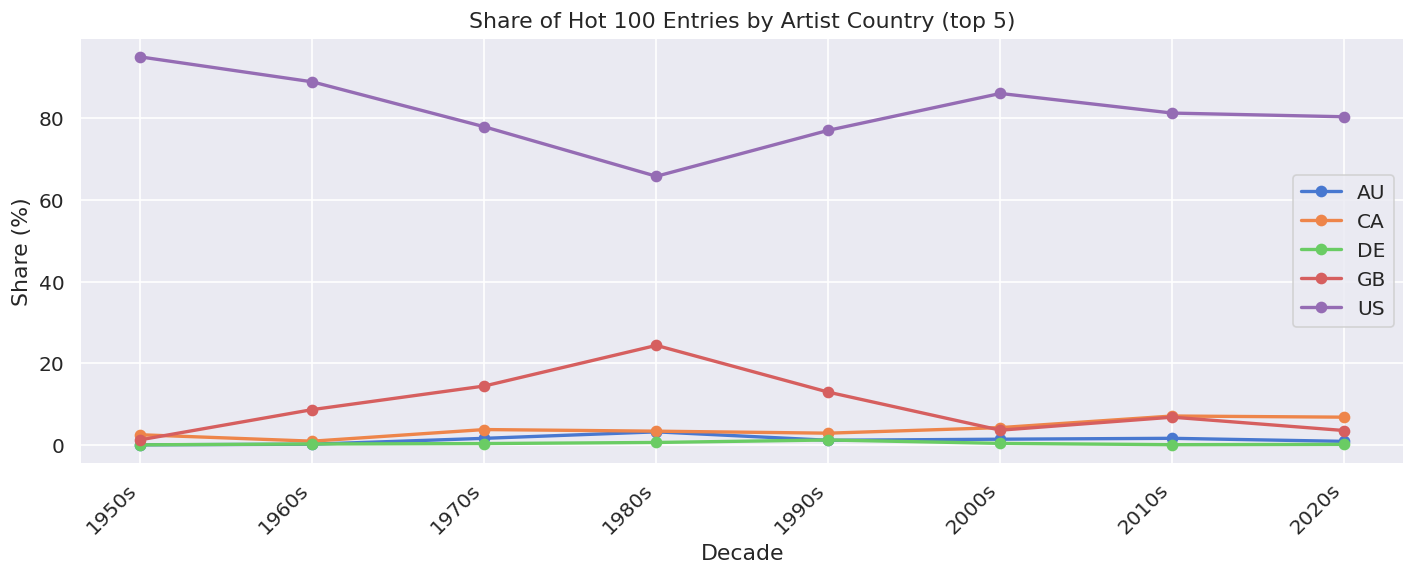

In [9]:
fig = plot_country_over_time(song_level, top_countries=5)
plt.show()


## 6. Chart Longevity — Are Hits Sticking Around Longer?
Streaming has changed how songs accumulate chart weeks.

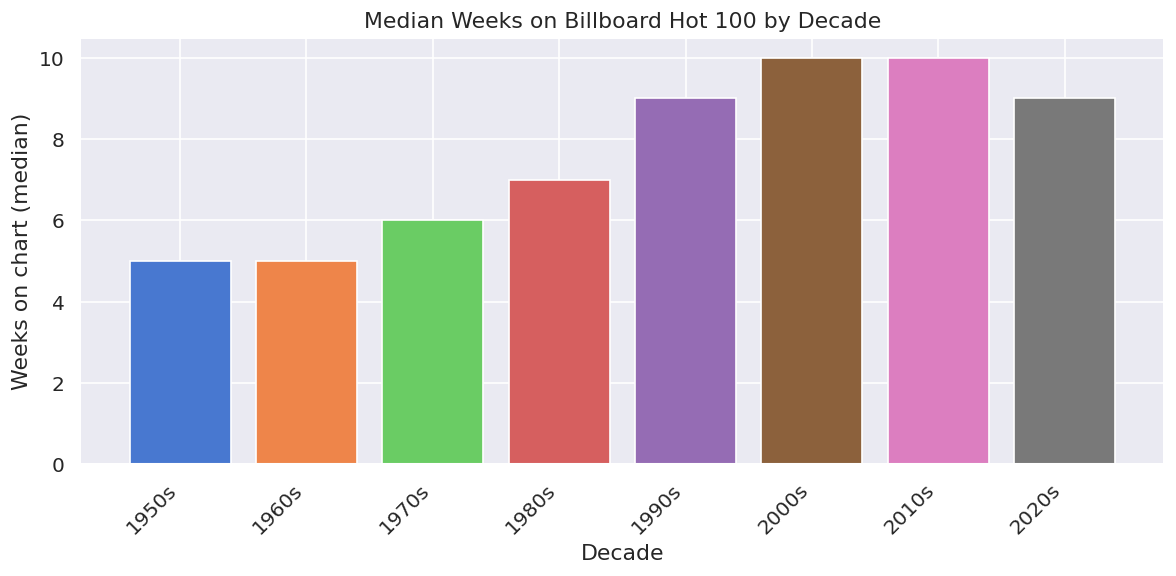

In [10]:
fig = plot_weeks_on_chart_over_time(df)
plt.show()

## 7. Are Streaming Songs Getting Shorter?

We split the timeline into four music-industry eras and test statistically whether
song duration has changed — not just visually.

| Era | Years |
|---|---|
| Pre-CD | 1958–1981 |
| CD / MTV | 1982–1999 |
| Download | 2000–2014 |
| Streaming | 2015–2024 |


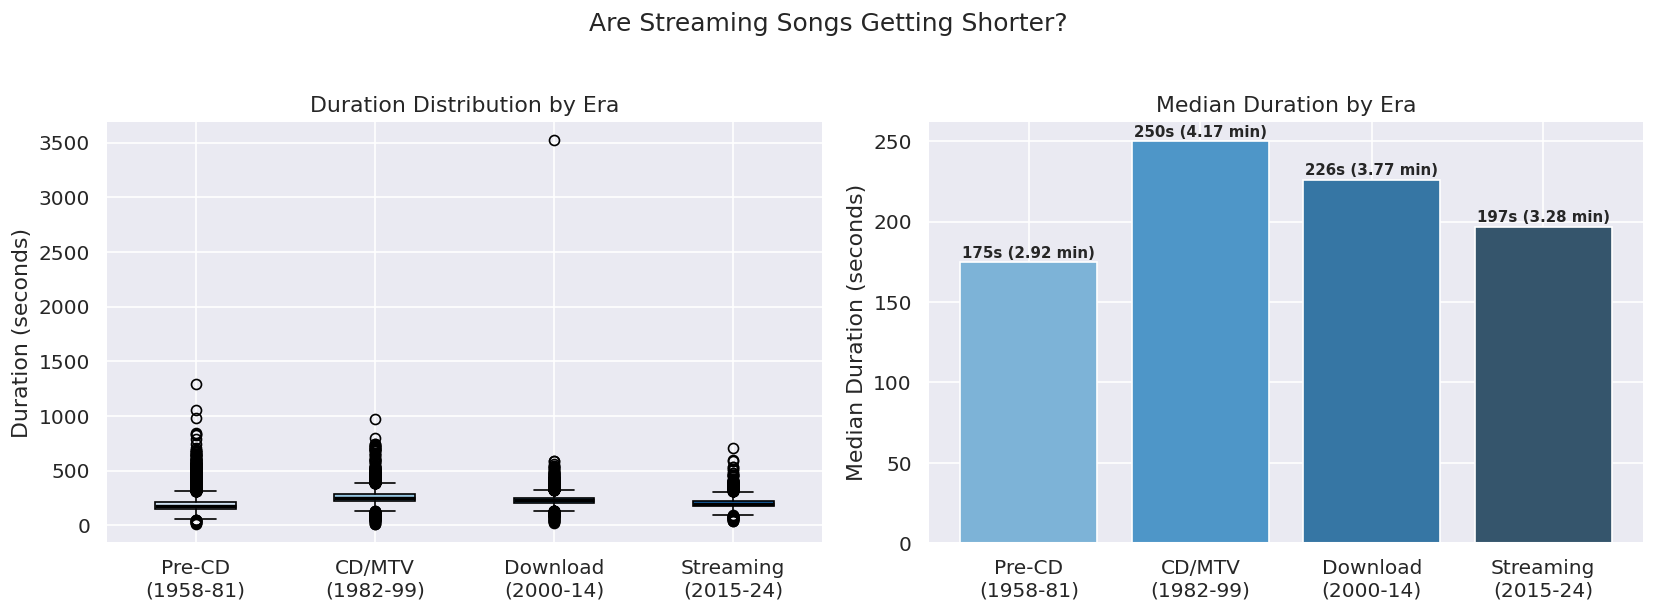

Mann-Whitney U test  (pre-streaming vs streaming era)
  n pre-streaming = 19,945   |   n streaming = 3,155
  U = 34,953,628,  p = 1.14e-23
  Median pre-streaming : 210.0s  (3.50 min)
  Median streaming era : 197.0s  (3.28 min)
  → Statistically significant difference at α = 0.05


In [11]:
era_bins   = [1957, 1981, 1999, 2014, 2025]
era_labels = ['Pre-CD\n(1958-81)', 'CD/MTV\n(1982-99)', 'Download\n(2000-14)', 'Streaming\n(2015-24)']

song_level['era'] = pd.cut(song_level['year'], bins=era_bins, labels=era_labels)
era_data = song_level.dropna(subset=['era', 'duration_sec'])
medians  = era_data.groupby('era', observed=True)['duration_sec'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp_data = [era_data[era_data['era'] == e]['duration_sec'].values for e in era_labels]
bplot = axes[0].boxplot(bp_data, labels=era_labels, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bplot['boxes'], sns.color_palette('Blues', 4)):
    patch.set_facecolor(color)
axes[0].set_title('Duration Distribution by Era')
axes[0].set_ylabel('Duration (seconds)')

axes[1].bar(era_labels, medians.values, color=sns.color_palette('Blues_d', 4), edgecolor='white')
for i, m in enumerate(medians.values):
    axes[1].text(i, m + 1, f'{m:.0f}s ({m/60:.2f} min)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Median Duration by Era')
axes[1].set_ylabel('Median Duration (seconds)')

plt.suptitle('Are Streaming Songs Getting Shorter?', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Mann-Whitney U test: pre-streaming vs streaming
pre_stream = era_data[era_data['year'] < 2015]['duration_sec']
streaming  = era_data[era_data['year'] >= 2015]['duration_sec']
stat, p = mannwhitneyu(pre_stream, streaming, alternative='two-sided')
print(f'Mann-Whitney U test  (pre-streaming vs streaming era)')
print(f'  n pre-streaming = {len(pre_stream):,}   |   n streaming = {len(streaming):,}')
print(f'  U = {stat:,.0f},  p = {p:.2e}')
print(f'  Median pre-streaming : {pre_stream.median():.1f}s  ({pre_stream.median()/60:.2f} min)')
print(f'  Median streaming era : {streaming.median():.1f}s  ({streaming.median()/60:.2f} min)')
print(f'  → {"Statistically significant difference" if p < 0.05 else "No significant difference"} at α = 0.05')


## 8. Genre vs Chart Longevity

Which genres produce the longest-charting songs?
Some genres might not appear most often, but when they chart they stay longer —
a more nuanced finding than just *genre share*.


,Songs,Median Weeks,Mean Weeks
broad_genre,,,
Country,2561,13.0,12.9
Dance/Electronic,1313,11.0,12.5
Rock,6073,11.0,11.8
R&B/Soul,4217,10.0,11.6
Folk,351,9.0,10.3
Pop,4708,9.0,10.9
Jazz,688,8.0,8.7
Latin,81,6.0,8.0
Hip-Hop/Rap,1990,5.0,9.2


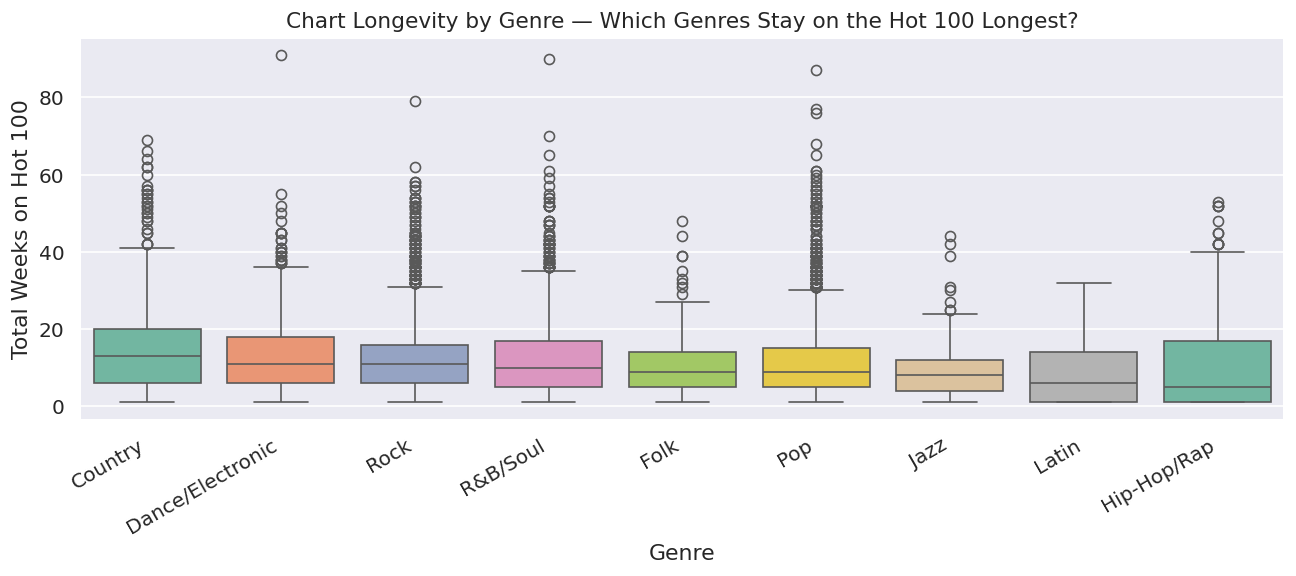

In [12]:
genre_longevity = (
    song_level.dropna(subset=['broad_genre', 'total_weeks'])
    .groupby('broad_genre', observed=True)['total_weeks']
    .agg(Songs='count', median_weeks='median', mean_weeks='mean')
    .sort_values('median_weeks', ascending=False)
    .rename(columns={'median_weeks': 'Median Weeks', 'mean_weeks': 'Mean Weeks'})
)
genre_longevity['Mean Weeks'] = genre_longevity['Mean Weeks'].round(1)
display(genre_longevity)

fig, ax = plt.subplots(figsize=(11, 5))
plot_data = song_level.dropna(subset=['broad_genre', 'total_weeks'])
sns.boxplot(
    data=plot_data, x='broad_genre', y='total_weeks',
    order=genre_longevity.index, palette='Set2', ax=ax
)
ax.set_title('Chart Longevity by Genre — Which Genres Stay on the Hot 100 Longest?', fontsize=13)
ax.set_ylabel('Total Weeks on Hot 100')
ax.set_xlabel('Genre')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 9. Peak Position vs Song Duration

Do shorter songs climb higher on the chart?  
We look at duration against peak position, then bin songs by length to find the
"sweet spot" that correlates with chart success.


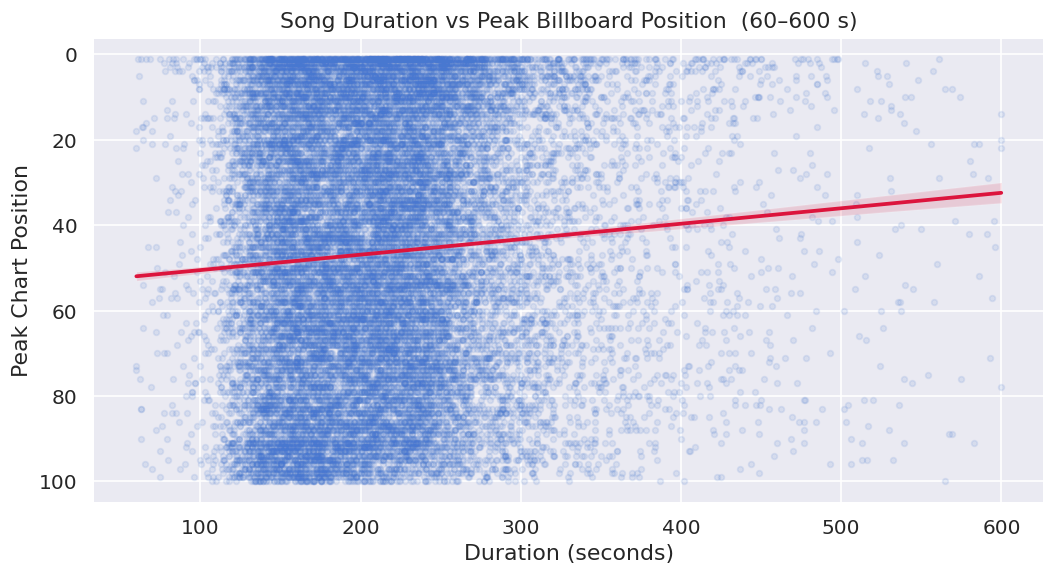

Duration bin vs chart performance:


,Songs,Median Peak Position,Median Weeks on Chart
duration_bin,,,
<2:30,3417,49.0,7.0
2:30-3:00,4338,50.0,8.0
3:00-3:30,4251,48.0,9.0
3:30-4:00,4398,44.0,12.0
4:00-5:00,4503,41.0,13.0
5:00+,2190,40.0,12.0


In [14]:
temp = (
    song_level
    .dropna(subset=['duration_sec', 'peak_position'])
    .query('60 <= duration_sec <= 600')   # remove extreme outliers
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(
    data=temp, x='duration_sec', y='peak_position',
    scatter_kws={'alpha': 0.12, 's': 12}, line_kws={'color': 'crimson'}, ax=ax
)
ax.invert_yaxis()
ax.set_title('Song Duration vs Peak Billboard Position  (60–600 s)')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Peak Chart Position')
plt.tight_layout()
plt.show()

# Duration bins
song_level['duration_bin'] = pd.cut(
    song_level['duration_sec'],
    bins=[0, 150, 180, 210, 240, 300, 1000],
    labels=['<2:30', '2:30-3:00', '3:00-3:30', '3:30-4:00', '4:00-5:00', '5:00+']
)
duration_success = (
    song_level.dropna(subset=['duration_bin'])
    .groupby('duration_bin', observed=True)
    .agg(
        Songs=('title', 'count'),
        median_peak=('peak_position', 'median'),
        median_weeks=('total_weeks', 'median'),
    )
    .rename(columns={'median_peak': 'Median Peak Position', 'median_weeks': 'Median Weeks on Chart'})
)
print('Duration bin vs chart performance:')
display(duration_success)
